In [5]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

from dataset import CoralDataModule
from model import CoralSegFormer

In [6]:
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False
torch.set_float32_matmul_precision("high")

In [7]:
user = "jrhowell"
dataset_dir = f"/home/{user}/sadow_koastore/shared/coral_seg/data/"
results_dir = f"/home/{user}/benthic_ecology_group/Jack/coral_seg/results/"
checkpoint_dir = f"{results_dir}/checkpoints_2.13.2026/"

# Pick the checkpoint you want to validate"
checkpoint_path = f"/home/{user}/benthic_ecology_group/Jack/coral_seg/results/checkpoints_2.13.2026/coral-segformer-epoch=01-val_loss=0.25.ckpt"

batch_size = 8
split_ratio = 0.8
num_workers = 4
samples_per_image = 100
crop_size = (512, 512)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)
print("Checkpoint path:", checkpoint_path)
print("Checkpoint exists:", Path(checkpoint_path).exists())

Using device: cuda
Checkpoint path: /home/jrhowell/benthic_ecology_group/Jack/coral_seg/results/checkpoints_2.13.2026/coral-segformer-epoch=01-val_loss=0.25.ckpt
Checkpoint exists: True


In [8]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("Seed set to", seed)

Seed set to 42


In [9]:
data_module = CoralDataModule(
    root_dir=dataset_dir,
    batch_size=batch_size,
    split_ratio=split_ratio,
    num_workers=num_workers,
    samples_per_image=samples_per_image,
    crop_size=crop_size,
)

data_module.setup()
val_loader = data_module.val_dataloader()

print("Number of validation image/mask pairs:", len(data_module.val_files))
print("Validation dataset length (random crops):", len(data_module.val_ds))
print("Validation batches:", len(val_loader))

Scanning /home/jrhowell/sadow_koastore/shared/coral_seg/data/...
Found 199 valid image/mask pairs.
Training on 159 images.
Validating on 40 images.
Number of validation image/mask pairs: 40
Validation dataset length (random crops): 4000
Validation batches: 500


In [10]:
example_batch = next(iter(val_loader))
images, masks = example_batch

print("Batch type:", type(example_batch))
print("Images shape:", images.shape)
print("Masks shape:", masks.shape)
print("Image dtype:", images.dtype)
print("Mask dtype:", masks.dtype)
print("Unique mask values in first batch:", torch.unique(masks))

Batch type: <class 'list'>
Images shape: torch.Size([8, 3, 512, 512])
Masks shape: torch.Size([8, 512, 512])
Image dtype: torch.float32
Mask dtype: torch.int64
Unique mask values in first batch: tensor([0, 1])


In [11]:
model = CoralSegFormer.load_from_checkpoint(checkpoint_path)
model.eval()
model.to(device)

print("Loaded checkpoint successfully")
print("Learning rate stored in checkpoint/model:", model.learning_rate)
print("Class mapping:", model.id2label)

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

Loaded checkpoint successfully
Learning rate stored in checkpoint/model: 0.0003
Class mapping: {0: 'background', 1: 'nv', 2: 'nh', 3: 'hy', 4: 'st-zo'}


In [12]:
def get_logits(model, images):
    outputs = model(images)
    if hasattr(outputs, "logits"):
        return outputs.logits
    return outputs


def align_logits_to_masks(logits, masks):
    if logits.shape[-2:] != masks.shape[-2:]:
        logits = F.interpolate(
            logits,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
    return logits


def compute_iou(preds, targets, num_classes):
    ious = []
    for cls in range(num_classes):
        pred_cls = preds == cls
        target_cls = targets == cls

        intersection = (pred_cls & target_cls).sum().item()
        union = (pred_cls | target_cls).sum().item()

        if union == 0:
            ious.append(np.nan)
        else:
            ious.append(intersection / union)
    return ious


def denormalize_image(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.detach().cpu() * std + mean
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    return img


def class_names_from_model(model):
    return [model.id2label[i] for i in range(len(model.id2label))]

In [13]:
images, masks = next(iter(val_loader))

print("before move:", images.shape, images.dtype, masks.shape, masks.dtype)

images = images[:1].to(device)
masks = masks[:1].to(device)

print("after move:", images.shape, images.device)
print("model device:", next(model.parameters()).device)

with torch.no_grad():
    logits = get_logits(model, images)
    logits = align_logits_to_masks(logits, masks)
    preds = torch.argmax(logits, dim=1)

print("logits shape:", logits.shape)
print("preds shape:", preds.shape)
print("done")

before move: torch.Size([8, 3, 512, 512]) torch.float32 torch.Size([8, 512, 512]) torch.int64
after move: torch.Size([1, 3, 512, 512]) cuda:0
model device: cuda:0
logits shape: torch.Size([1, 5, 512, 512])
preds shape: torch.Size([1, 512, 512])
done


In [16]:
example_cache = []

images, masks = next(iter(val_loader))

images = images[:1].to(device)
masks = masks[:1].to(device)

with torch.no_grad():
    logits = get_logits(model, images)
    logits = align_logits_to_masks(logits, masks)
    preds = torch.argmax(logits, dim=1)

example_cache.append({
    "image": images[0].detach().cpu(),
    "target": masks[0].detach().cpu(),
    "pred": preds[0].detach().cpu(),
})

print("example_cache length:", len(example_cache))

example_cache length: 1


In [17]:
preds_list = []
targets_list = []

for sample in example_cache:
    preds_list.append(sample["pred"].unsqueeze(0))
    targets_list.append(sample["target"].unsqueeze(0))

all_preds = torch.cat(preds_list, dim=0)
all_targets = torch.cat(targets_list, dim=0)

num_classes = len(model.id2label)

pixel_acc = (all_preds == all_targets).float().mean().item()
ious = compute_iou(all_preds, all_targets, num_classes)
mean_iou = np.nanmean(ious)

class_names = class_names_from_model(model)

print(f"Pixel accuracy: {pixel_acc:.4f}")

for cls_idx, cls_iou in enumerate(ious):
    name = class_names[cls_idx]
    if np.isnan(cls_iou):
        print(f"{cls_idx} ({name}) IoU: NA")
    else:
        print(f"{cls_idx} ({name}) IoU: {cls_iou:.4f}")

print(f"Mean IoU: {mean_iou:.4f}")

Pixel accuracy: 0.9885
0 (background) IoU: 0.9875
1 (nv) IoU: 0.8820
2 (nh) IoU: NA
3 (hy) IoU: NA
4 (st-zo) IoU: NA
Mean IoU: 0.9348


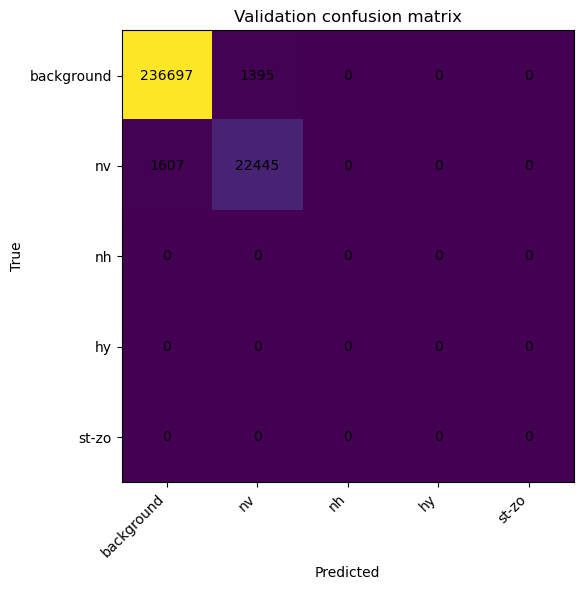

In [18]:
cm = np.zeros((num_classes, num_classes), dtype=np.int64)
flat_targets = all_targets.view(-1).numpy()
flat_preds = all_preds.view(-1).numpy()

for t, p in zip(flat_targets, flat_preds):
    cm[t, p] += 1

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm)
ax.set_title("Validation confusion matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

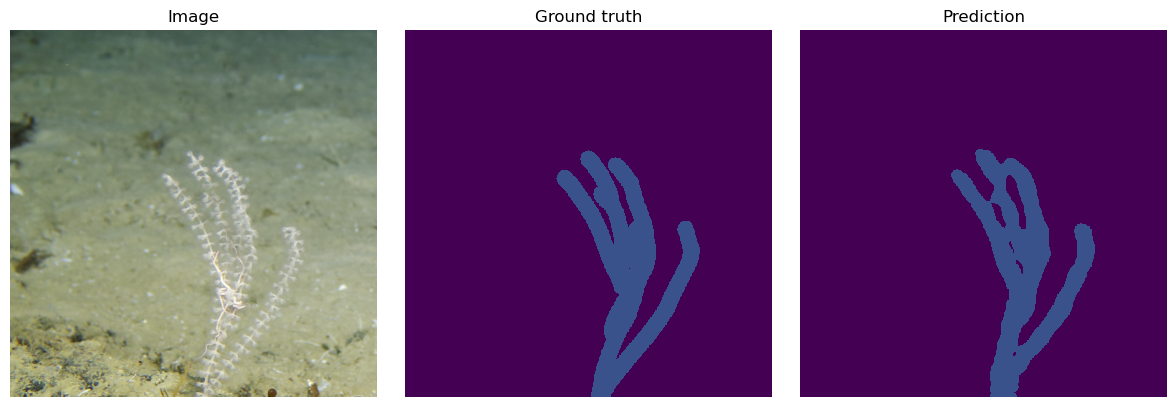

In [19]:
n_show = min(6, len(example_cache))
fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))

if n_show == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n_show):
    sample = example_cache[row]
    img = denormalize_image(sample["image"])
    target = sample["target"].numpy()
    pred = sample["pred"].numpy()

    axes[row, 0].imshow(img)
    axes[row, 0].set_title("Image")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(target, interpolation="nearest", vmin=0, vmax=num_classes - 1)
    axes[row, 1].set_title("Ground truth")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(pred, interpolation="nearest", vmin=0, vmax=num_classes - 1)
    axes[row, 2].set_title("Prediction")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

In [20]:
scores = []
for idx, sample in enumerate(example_cache):
    sample_acc = (sample["pred"] == sample["target"]).float().mean().item()
    scores.append((idx, sample_acc))

scores_sorted = sorted(scores, key=lambda x: x[1])
scores_sorted

[(0, 0.9885482788085938)]

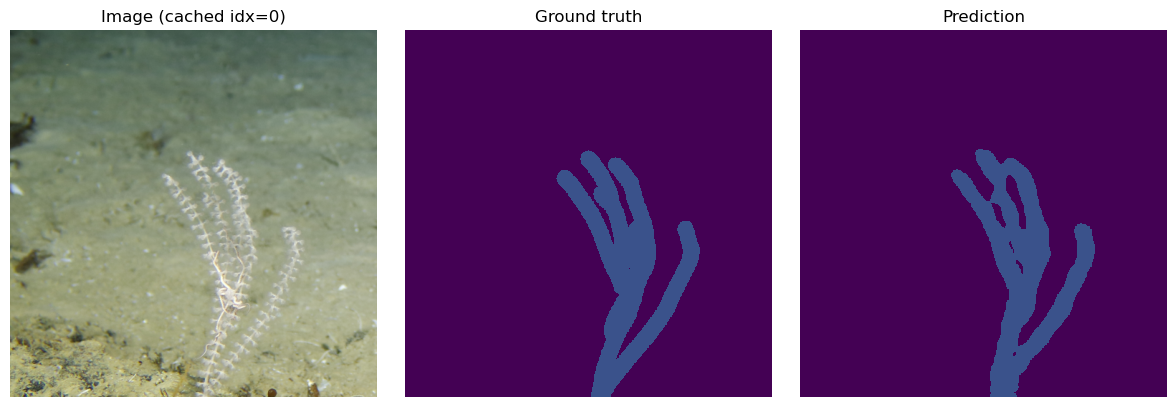

In [21]:
example_idx = scores_sorted[0][0]  # worst cached example by default

sample = example_cache[example_idx]
img = denormalize_image(sample["image"])
target = sample["target"].numpy()
pred = sample["pred"].numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img)
axes[0].set_title(f"Image (cached idx={example_idx})")
axes[0].axis("off")

axes[1].imshow(target, interpolation="nearest", vmin=0, vmax=num_classes - 1)
axes[1].set_title("Ground truth")
axes[1].axis("off")

axes[2].imshow(pred, interpolation="nearest", vmin=0, vmax=num_classes - 1)
axes[2].set_title("Prediction")
axes[2].axis("off")

plt.tight_layout()
plt.show()